In [246]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import seaborn as sns

from sklearn.metrics import classification_report , f1_score , precision_score , recall_score, confusion_matrix , make_scorer
from sklearn.model_selection import KFold, train_test_split, GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import  GradientBoostingClassifier


from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import pickle

In [ ]:
df = pd.read_csv("../data/imbalanced_preprocessed_1.csv")
# df = pd.read_csv("../data/balanced_preprocessed_1.csv")

# df = pd.read_csv("../data/imbalanced_pca_2.csv")
# df = pd.read_csv("../data/balanced_pca_2.csv")





df.columns

Index(['dynamics_rms_mean', 'dynamics_rms_std', 'pitch_pitch_mean',
       'rhythm_attacktime_mean', 'rhythm_eventdensity_mean',
       'rhythm_fluctuationmax_peakposmean', 'rhythm_pulseclarity_mean',
       'rhythm_tempo_mean', 'rhythm_tempo_std', 'spectral_brightness_mean',
       'spectral_brightness_std', 'spectral_centroid_mean',
       'spectral_centroid_std', 'spectral_flatness_mean',
       'spectral_flatness_std', 'spectral_inharmonicity_mean',
       'spectral_irregularity_mean', 'spectral_kurtosis_mean',
       'spectral_kurtosis_std', 'spectral_mfcc_mean_1',
       'spectral_mfcc_mean_10', 'spectral_mfcc_mean_11',
       'spectral_mfcc_mean_12', 'spectral_mfcc_mean_13',
       'spectral_mfcc_mean_2', 'spectral_mfcc_mean_3', 'spectral_mfcc_mean_4',
       'spectral_mfcc_mean_5', 'spectral_mfcc_mean_6', 'spectral_mfcc_mean_7',
       'spectral_mfcc_mean_8', 'spectral_mfcc_mean_9', 'spectral_mfcc_std_1',
       'spectral_mfcc_std_10', 'spectral_mfcc_std_11', 'spectral_mfcc_std

In [ ]:


# features_all = ['dynamics_rms_mean', 'dynamics_rms_std',
#        'pitch_pitch_mean', 'rhythm_attacktime_mean',
#        'rhythm_eventdensity_mean', 'rhythm_fluctuationmax_peakposmean',
#        'rhythm_pulseclarity_mean', 'rhythm_tempo_mean', 'rhythm_tempo_std',
#        'spectral_brightness_mean', 'spectral_brightness_std',
#        'spectral_centroid_mean', 'spectral_centroid_std',
#        'spectral_flatness_mean', 'spectral_flatness_std',
#        'spectral_inharmonicity_mean', 'spectral_irregularity_mean',
#        'spectral_kurtosis_mean', 'spectral_kurtosis_std',
#        'spectral_mfcc_mean_1', 'spectral_mfcc_mean_10',
#        'spectral_mfcc_mean_11', 'spectral_mfcc_mean_12',
#        'spectral_mfcc_mean_13', 'spectral_mfcc_mean_2', 'spectral_mfcc_mean_3',
#        'spectral_mfcc_mean_4', 'spectral_mfcc_mean_5', 'spectral_mfcc_mean_6',
#        'spectral_mfcc_mean_7', 'spectral_mfcc_mean_8', 'spectral_mfcc_mean_9',
#        'spectral_mfcc_std_1', 'spectral_mfcc_std_10', 'spectral_mfcc_std_11',
#        'spectral_mfcc_std_12', 'spectral_mfcc_std_13', 'spectral_mfcc_std_2',
#        'spectral_mfcc_std_3', 'spectral_mfcc_std_4', 'spectral_mfcc_std_5',
#        'spectral_mfcc_std_6', 'spectral_mfcc_std_7', 'spectral_mfcc_std_8',
#        'spectral_mfcc_std_9', 'spectral_novelty_mean', 'spectral_novelty_std',
#        'spectral_rolloff85_mean', 'spectral_rolloff85_std',
#        'spectral_rolloff95_mean', 'spectral_rolloff95_std',
#        'spectral_roughness_mean', 'spectral_skewness_mean',
#        'spectral_skewness_std', 'spectral_spectentropy_mean',
#        'spectral_spectentropy_std', 'spectral_spread_mean',
#        'spectral_spread_std', 'timbre_lowenergy_mean', 'timbre_lowenergy_std',
#        'timbre_spectralflux_mean', 'timbre_spectralflux_std',
#        'tonal_hcdf_mean', 'tonal_hcdf_std', 'tonal_keyclarity_mean',
#        'tonal_keyclarity_std', 'tonal_mode_mean', 'tonal_mode_std']



# feature_pca

# features_xgb = ['spectral_roughness_mean', 'spectral_centroid_mean',
#        'spectral_spectentropy_mean', 'spectral_brightness_mean',
#        'spectral_kurtosis_std', 'spectral_mfcc_std_10',
#        'spectral_mfcc_std_8', 'spectral_mfcc_std_13',
#        'spectral_mfcc_std_11', 'timbre_lowenergy_std']


# features_rfe_gbc = ['dynamics_rms_mean', 'pitch_pitch_mean',
#        'rhythm_fluctuationmax_peakposmean', 'spectral_brightness_mean',
#        'spectral_centroid_std', 'spectral_mfcc_std_4',
#        'spectral_mfcc_std_6', 'spectral_roughness_mean',
#        'spectral_spread_std', 'timbre_lowenergy_std']


# features_pca_im = ['0', '1', '4', '5', '6', '8', '11', '17', '20', '28']

# features_pca_b = ['0', '1', '4', '6', '9', '11', '17', '20', '22', '34']




In [321]:
# Separate features (X) and target (y)
X = df[features_xgb]
y = df["Category"]



# X = df.drop(["Category"] , axis= 1)
# y = df["Category"]



In [322]:
# Split into train (80%) and temp (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [323]:
# Print dataset sizes
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (582, 10)
Test set size: (146, 10)


In [324]:
def w_f1_score(y_test , y_pred) :
    return f1_score(y_test , y_pred , average = "macro")


cs = make_scorer(w_f1_score)

In [ ]:
# model = GradientBoostingClassifier()

# # Define the search space
# search_space = {
#     'n_estimators': Integer(20, 500),
#     'learning_rate': Real(0.01, 0.3),
#     'max_depth': Integer(3, 10),
#     'min_samples_split': Integer(2, 10),
#     'min_samples_leaf': Integer(1, 5)
# }


model = KNeighborsClassifier()

search_space = {
    'n_neighbors': np.arange(1, 21),  # Searching for best k in range 1-20
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # Different distance metrics
    'algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'weights' : ['uniform' , 'distance']
}


In [326]:


cv = KFold(n_splits=5 ,shuffle= True, random_state=42)

# Perform Bayesian Optimization with Cross-Validation
bayes_search = BayesSearchCV(model , search_spaces=search_space, n_iter=30, cv=cv, scoring= cs , n_jobs=-1, random_state=42)
bayes_search.fit(X_train, y_train)

# Best parameters and cross-validation accuracy
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation F1:", bayes_search.best_score_)


Best Parameters: OrderedDict({'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 2, 'weights': 'distance'})
Best Cross-Validation F1: 0.5623863435695


In [327]:

# cv = KFold(n_splits=5 ,shuffle= True, random_state=42)

# # Perform Bayesian Optimization with Cross-Validation
# gs = GridSearchCV(model , param_grid=search_space, cv=cv, scoring= cs , n_jobs=-1)
# gs.fit(X_train, y_train)

# # Best parameters and cross-validation accuracy
# print("Best Parameters:", gs.best_params_)
# print("Best Cross-Validation F1:", gs.best_score_)

In [328]:
# model = GradientBoostingClassifier(**bayes_search.best_params_)
model =  KNeighborsClassifier(**bayes_search.best_params_)

In [329]:
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

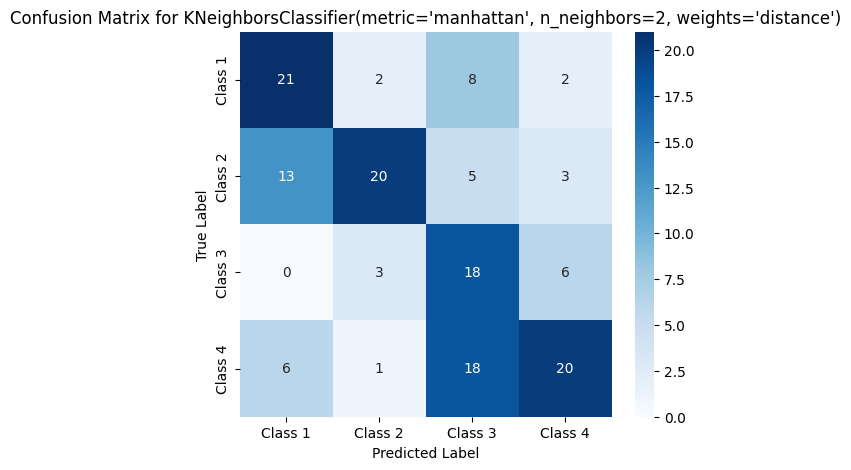

In [330]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
class_names = ['Class 1', 'Class 2', 'Class 3', 'Class 4']

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix for {model}")
plt.show()

In [331]:

# Best parameters and cross-validation accuracy
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation F1:", bayes_search.best_score_)

print(classification_report(y_test , y_pred))


precision = precision_score(y_test , y_pred , average= "weighted")
f1 = f1_score(y_test , y_pred , average= "weighted")
recall = recall_score(y_test , y_pred , average= "weighted")


print(f"{precision= } {f1= } {recall= }")




Best Parameters: OrderedDict({'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 2, 'weights': 'distance'})
Best Cross-Validation F1: 0.5623863435695
              precision    recall  f1-score   support

     Class 1       0.53      0.64      0.58        33
     Class 2       0.77      0.49      0.60        41
     Class 3       0.37      0.67      0.47        27
     Class 4       0.65      0.44      0.53        45

    accuracy                           0.54       146
   macro avg       0.58      0.56      0.54       146
weighted avg       0.60      0.54      0.55       146

precision= 0.6014663489720304 f1= 0.5475177912375879 recall= 0.541095890410959


In [332]:
print(f1_score(y_test , y_pred , average = "macro"))

0.5430893477816398
